In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc

In [25]:
from ucimlrepo import fetch_ucirepo 
heart_disease = fetch_ucirepo(id=45) 
  
X = heart_disease.data.features 
y = heart_disease.data.targets 


In [26]:
df = X
df['target'] = y

df['target'] = (df['target'] > 0).astype(int)
df['target'].value_counts()

target
0    164
1    139
Name: count, dtype: int64

## Exploratory analysis

In [27]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [28]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

## Training the models

In [29]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
ct = continuous_cols = ['oldpeak', 'thalach']
ordinal_cols = ['ca', 'slope']
passthrough_cols = ['exang']
nominal_cols = ['cp', 'thal']

numeric_all = continuous_cols + ordinal_cols
k_range = list(range(1, 30))

ct = ColumnTransformer([
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('scaler', StandardScaler()),
        ]), numeric_all),
        ('passthrough', 'passthrough', passthrough_cols),
        ('ohe', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), nominal_cols),
    ])

In [31]:
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(ct.fit_transform(X_train))
X_test_pca = pca.transform(ct.transform(X_test))

In [32]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(ct.fit_transform(X_train), y_train)
X_test_lda = lda.transform(ct.transform(X_test))

### KNN

Best params: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 27, 'classifier__p': 1, 'classifier__weights': 'distance'}
Best CV accuracy: 0.843
Test accuracy: 0.9016

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91        33
           1       0.89      0.89      0.89        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



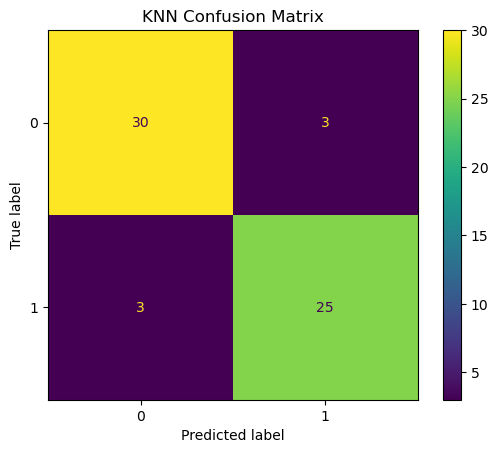

In [56]:
knn_pipeline = Pipeline([
    ('preprocessor', ct),
    ('classifier', KNeighborsClassifier())
])

knn_param_grid = {
    'classifier__n_neighbors': list(range(1, 31)),
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski'],
    'classifier__p': [1, 2],
}

knn_grid = GridSearchCV(
    knn_pipeline, knn_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, refit=True, verbose=0
)
knn_grid.fit(X_train, y_train)

print('Best params:', knn_grid.best_params_)
print('Best CV accuracy:', round(knn_grid.best_score_, 4))

y_pred_knn = knn_grid.predict(X_test)
print('Test accuracy:', round(accuracy_score(y_test, y_pred_knn), 4))
print('\nClassification Report:\n', classification_report(y_test, y_pred_knn))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title('KNN Confusion Matrix')
plt.show()

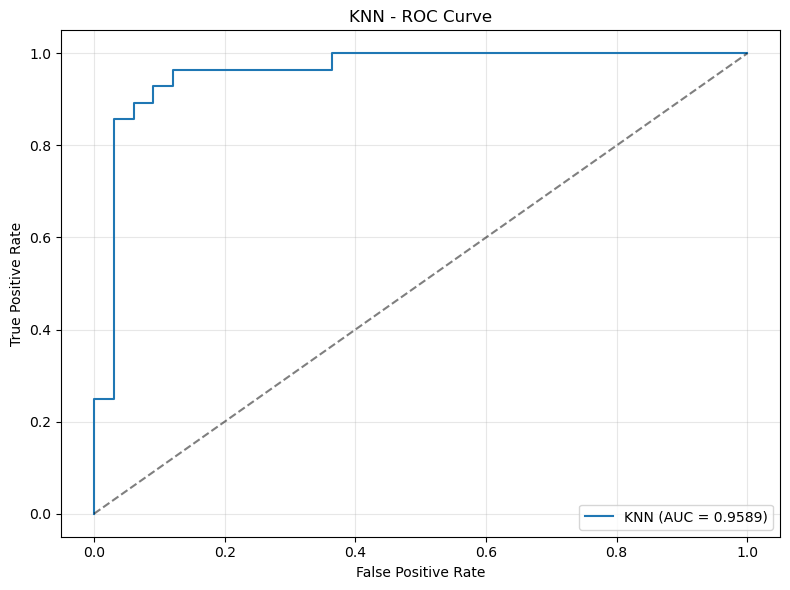

In [57]:
y_proba_knn = knn_grid.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN - ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

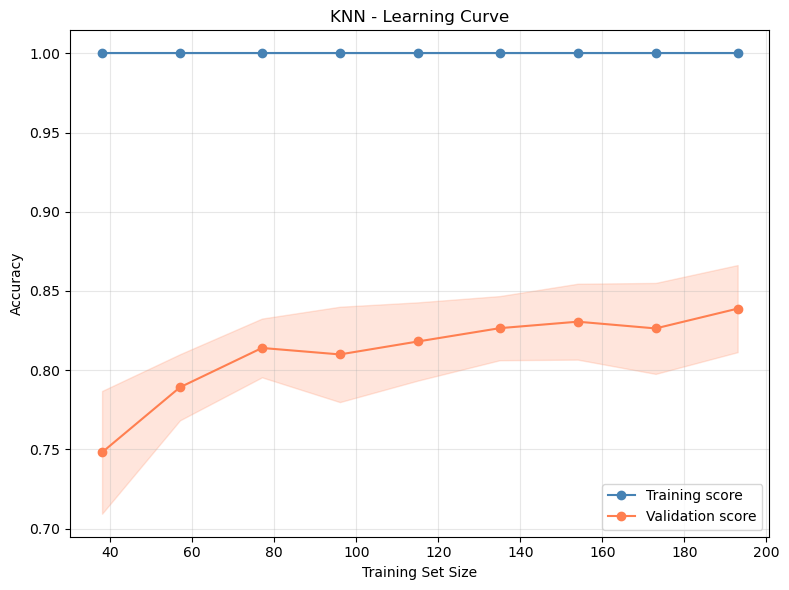

In [58]:
train_sizes, train_scores, val_scores = learning_curve(
    knn_grid.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='coral', label='Validation score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='coral')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('KNN - Learning Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Como weights = distance - O modelo memoriza perfeitamente o conjunto de treino, classificando cada observação com sua própria classo pois 1/d se d = 0 -> chains. Mas não significa overfit, é o comportamento esperado dado o parâmetro. O gridsearch garante a melhor generalização para o modelo. 

Text(0.5, 1.0, 'KNN - Validation Curve for n_neighbors')

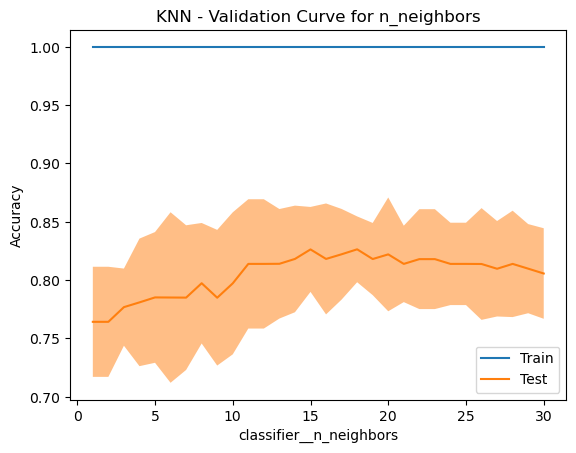

In [59]:
from sklearn.model_selection import ValidationCurveDisplay

ValidationCurveDisplay.from_estimator(
    knn_grid.best_estimator_,
    X_train,
    y_train,
    param_name="classifier__n_neighbors",
    param_range=range(1, 31),
    cv=5,
    scoring="accuracy"
)

plt.title('KNN - Validation Curve for n_neighbors')

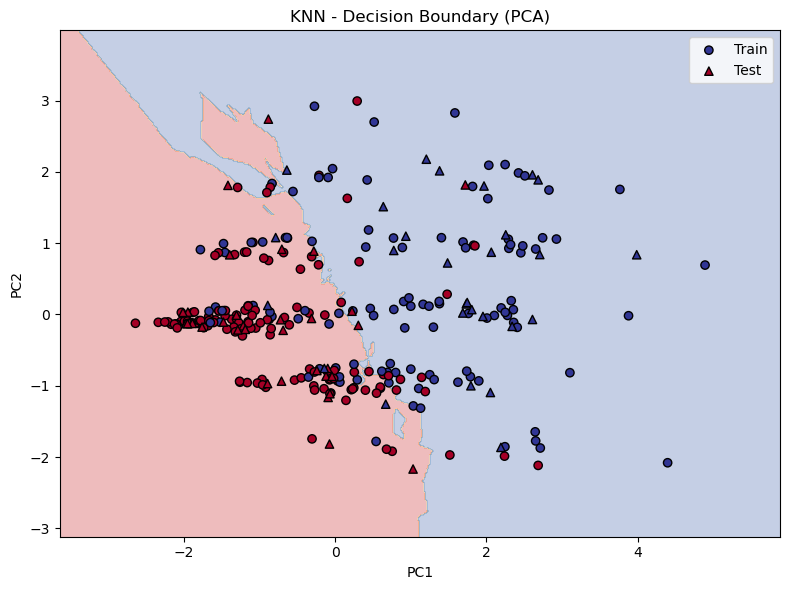

In [36]:
clf_pca = clone(knn_grid.best_estimator_.named_steps['classifier'])
clf_pca.fit(X_train_pca, y_train)

n_pc = X_train_pca.shape[1]

if n_pc == 1:
    x_min, x_max = X_train_pca.min() - 0.5, X_train_pca.max() + 0.5
    x_range = np.linspace(x_min, x_max, 1000).reshape(-1, 1)
    Z = clf_pca.predict(x_range)
    fig, ax = plt.subplots(figsize=(10, 2))
    for label, color in zip([0, 1], ['#cce5ff', '#ffcccc']):
        mask = Z.ravel() == label
        ax.axvspan(x_range[mask].min(), x_range[mask].max(), alpha=0.3, color=color)
    ax.scatter(X_train_pca[y_train == 0], np.zeros_like(X_train_pca[y_train == 0]),
               c='steelblue', edgecolors='k', s=40, label='Train 0', zorder=5)
    ax.scatter(X_train_pca[y_train == 1], np.zeros_like(X_train_pca[y_train == 1]),
               c='coral', edgecolors='k', s=40, label='Train 1', zorder=5, marker='s')
    ax.scatter(X_test_pca[y_test == 0], np.full_like(X_test_pca[y_test == 0], -0.1),
               c='steelblue', edgecolors='k', s=40, marker='^', label='Test 0', zorder=5)
    ax.scatter(X_test_pca[y_test == 1], np.full_like(X_test_pca[y_test == 1], -0.1),
               c='coral', edgecolors='k', s=40, marker='^', label='Test 1', zorder=5)
    ax.set_yticks([])
    ax.set_xlabel('PC1')
    ax.set_title('KNN - Decision Boundary (PCA 1D)')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
else:
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    if n_pc > 2:
        pad = np.zeros((grid_points.shape[0], n_pc - 2))
        grid_points = np.hstack([grid_points, pad])
    Z = clf_pca.predict(grid_points)
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.RdYlBu, label='Train')
    plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.RdYlBu, marker='^', label='Test')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('KNN - Decision Boundary (PCA)')
    plt.legend()
plt.tight_layout()
plt.show()

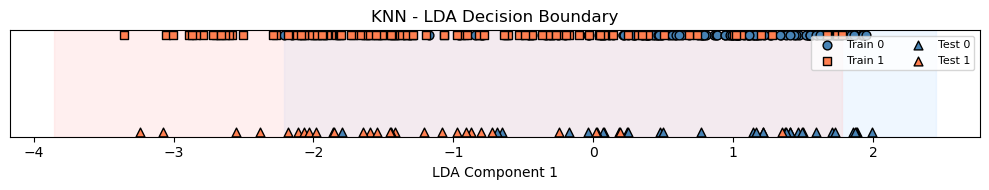

In [37]:

clf_lda = clone(knn_grid.best_estimator_.named_steps['classifier'])
clf_lda.fit(X_train_lda, y_train)

x_min, x_max = X_train_lda.min() - 0.5, X_train_lda.max() + 0.5
x_range = np.linspace(x_min, x_max, 1000).reshape(-1, 1)

Z = clf_lda.predict(x_range)

fig, ax = plt.subplots(figsize=(10, 2))
for label, color in zip([0, 1], ['#cce5ff', '#ffcccc']):
    mask = Z.ravel() == label
    ax.axvspan(x_range[mask].min(), x_range[mask].max(), alpha=0.3, color=color)

ax.scatter(X_train_lda[y_train == 0], np.zeros_like(X_train_lda[y_train == 0]),
           c='steelblue', edgecolors='k', s=40, label='Train 0', zorder=5)
ax.scatter(X_train_lda[y_train == 1], np.zeros_like(X_train_lda[y_train == 1]),
           c='coral', edgecolors='k', s=40, label='Train 1', zorder=5, marker='s')
ax.scatter(X_test_lda[y_test == 0], np.full_like(X_test_lda[y_test == 0], -0.1),
           c='steelblue', edgecolors='k', s=40, marker='^', label='Test 0', zorder=5)
ax.scatter(X_test_lda[y_test == 1], np.full_like(X_test_lda[y_test == 1], -0.1),
           c='coral', edgecolors='k', s=40, marker='^', label='Test 1', zorder=5)

ax.set_yticks([])
ax.set_xlabel('LDA Component 1')
ax.set_title('KNN - LDA Decision Boundary')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Logistic Regression

Best params: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV accuracy: 0.8471
Test accuracy: 0.8852

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



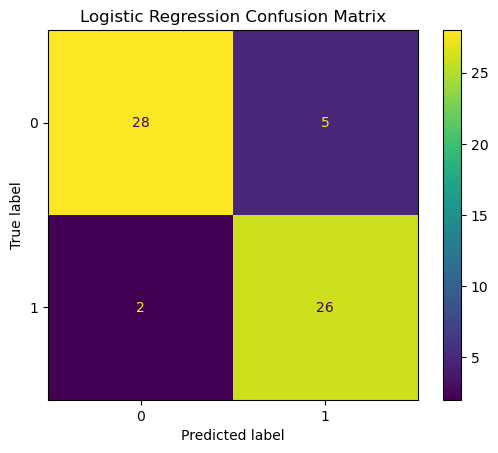

In [38]:
lr_pipeline = Pipeline([
    ('preprocessor', ct),
    ('classifier', LogisticRegression(max_iter=1000))
])

lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': [None, 'balanced'],
}

lr_grid = GridSearchCV(
    lr_pipeline, lr_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, refit=True, verbose=0
)
lr_grid.fit(X_train, y_train)

print('Best params:', lr_grid.best_params_)
print('Best CV accuracy:', round(lr_grid.best_score_, 4))

y_pred_lr = lr_grid.predict(X_test)
print('Test accuracy:', round(accuracy_score(y_test, y_pred_lr), 4))
print('\nClassification Report:\n', classification_report(y_test, y_pred_lr))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

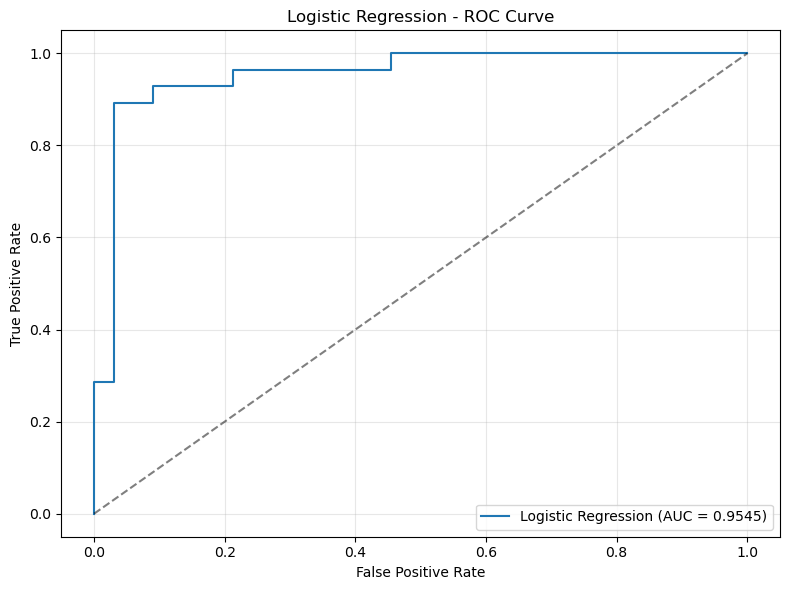

In [39]:
y_proba_lr = lr_grid.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression - ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

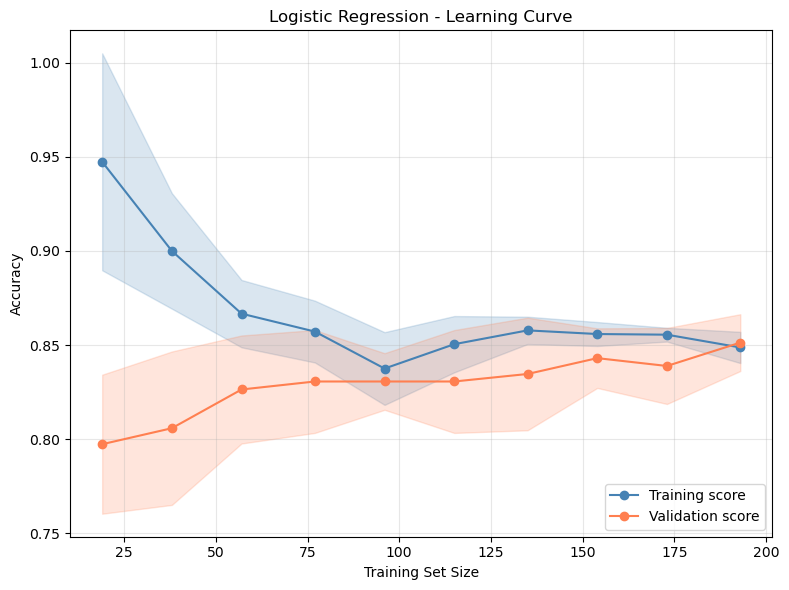

In [40]:
train_sizes, train_scores, val_scores = learning_curve(
    lr_grid.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='coral', label='Validation score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='coral')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Logistic Regression - Learning Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

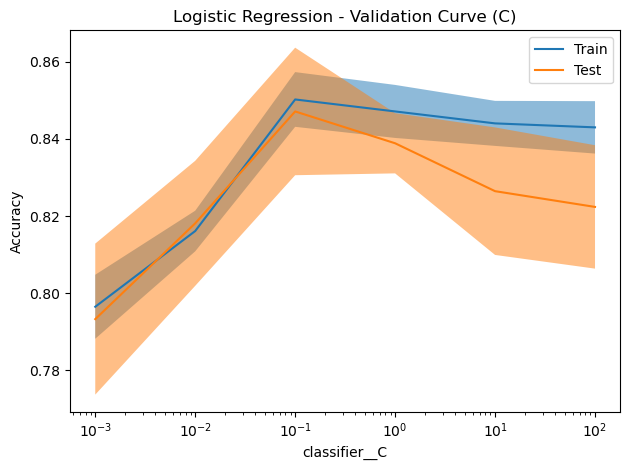

In [61]:
from sklearn.model_selection import ValidationCurveDisplay

ValidationCurveDisplay.from_estimator(
    lr_grid.best_estimator_,
    X_train,
    y_train,
    param_name="classifier__C",
    param_range=[0.001, 0.01, 0.1, 1, 10, 100],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy"
)
plt.title('Logistic Regression - Validation Curve (C)')
plt.tight_layout()
plt.show()

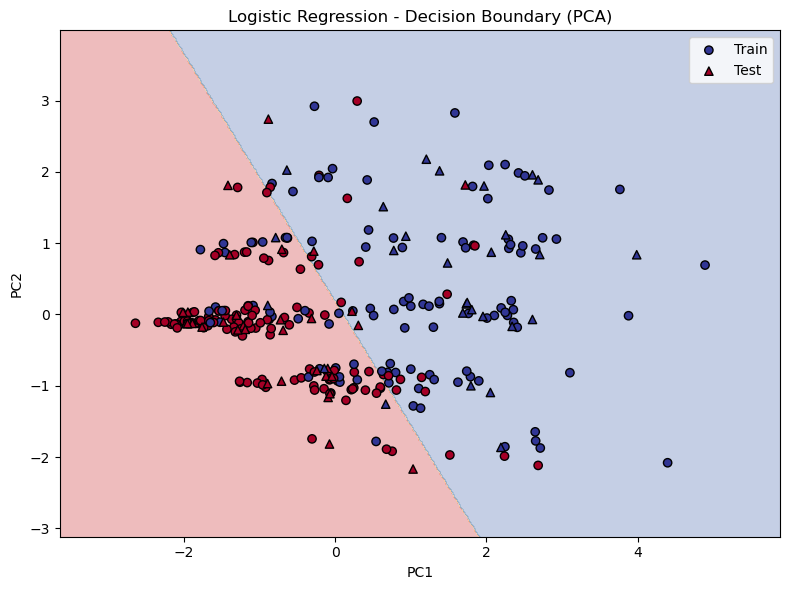

In [41]:
clf_pca = clone(lr_grid.best_estimator_.named_steps['classifier'])
clf_pca.fit(X_train_pca, y_train)

n_pc = X_train_pca.shape[1]

if n_pc == 1:
    x_min, x_max = X_train_pca.min() - 0.5, X_train_pca.max() + 0.5
    x_range = np.linspace(x_min, x_max, 1000).reshape(-1, 1)
    Z = clf_pca.predict(x_range)
    fig, ax = plt.subplots(figsize=(10, 2))
    for label, color in zip([0, 1], ['#cce5ff', '#ffcccc']):
        mask = Z.ravel() == label
        ax.axvspan(x_range[mask].min(), x_range[mask].max(), alpha=0.3, color=color)
    ax.scatter(X_train_pca[y_train == 0], np.zeros_like(X_train_pca[y_train == 0]),
               c='steelblue', edgecolors='k', s=40, label='Train 0', zorder=5)
    ax.scatter(X_train_pca[y_train == 1], np.zeros_like(X_train_pca[y_train == 1]),
               c='coral', edgecolors='k', s=40, label='Train 1', zorder=5, marker='s')
    ax.scatter(X_test_pca[y_test == 0], np.full_like(X_test_pca[y_test == 0], -0.1),
               c='steelblue', edgecolors='k', s=40, marker='^', label='Test 0', zorder=5)
    ax.scatter(X_test_pca[y_test == 1], np.full_like(X_test_pca[y_test == 1], -0.1),
               c='coral', edgecolors='k', s=40, marker='^', label='Test 1', zorder=5)
    ax.set_yticks([])
    ax.set_xlabel('PC1')
    ax.set_title('Logistic Regression - Decision Boundary (PCA 1D)')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
else:
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    if n_pc > 2:
        pad = np.zeros((grid_points.shape[0], n_pc - 2))
        grid_points = np.hstack([grid_points, pad])
    Z = clf_pca.predict(grid_points)
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.RdYlBu, label='Train')
    plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.RdYlBu, marker='^', label='Test')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Logistic Regression - Decision Boundary (PCA)')
    plt.legend()
plt.tight_layout()
plt.show()

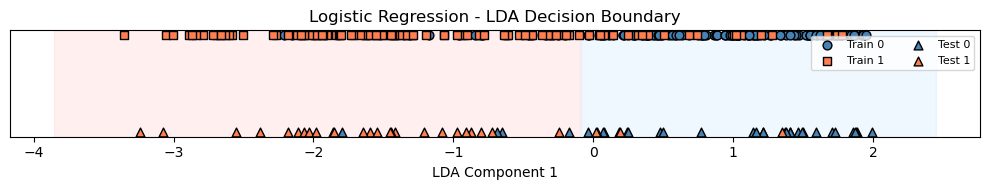

In [42]:
clf_lda = clone(lr_grid.best_estimator_.named_steps['classifier'])
clf_lda.fit(X_train_lda, y_train)

x_min, x_max = X_train_lda.min() - 0.5, X_train_lda.max() + 0.5
x_range = np.linspace(x_min, x_max, 1000).reshape(-1, 1)

Z = clf_lda.predict(x_range)

fig, ax = plt.subplots(figsize=(10, 2))
for label, color in zip([0, 1], ['#cce5ff', '#ffcccc']):
    mask = Z.ravel() == label
    ax.axvspan(x_range[mask].min(), x_range[mask].max(), alpha=0.3, color=color)

ax.scatter(X_train_lda[y_train == 0], np.zeros_like(X_train_lda[y_train == 0]),
           c='steelblue', edgecolors='k', s=40, label='Train 0', zorder=5)
ax.scatter(X_train_lda[y_train == 1], np.zeros_like(X_train_lda[y_train == 1]),
           c='coral', edgecolors='k', s=40, label='Train 1', zorder=5, marker='s')
ax.scatter(X_test_lda[y_test == 0], np.full_like(X_test_lda[y_test == 0], -0.1),
           c='steelblue', edgecolors='k', s=40, marker='^', label='Test 0', zorder=5)
ax.scatter(X_test_lda[y_test == 1], np.full_like(X_test_lda[y_test == 1], -0.1),
           c='coral', edgecolors='k', s=40, marker='^', label='Test 1', zorder=5)

ax.set_yticks([])
ax.set_xlabel('LDA Component 1')
ax.set_title('Logistic Regression - LDA Decision Boundary')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### SVM

Best params: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Best CV accuracy: 0.843
Test accuracy: 0.9016

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



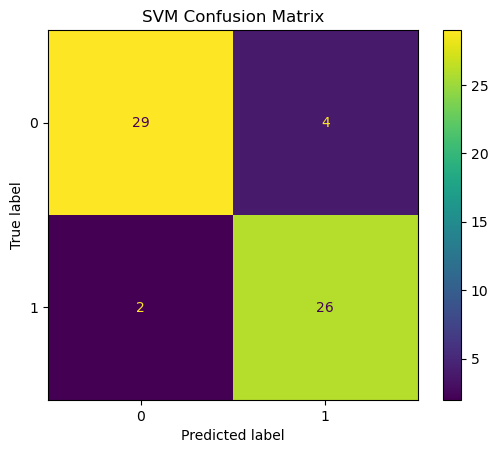

In [43]:
svm_pipeline = Pipeline([
    ('preprocessor', ct),
    ('classifier', SVC())
])

svm_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__kernel': ['linear', 'rbf', 'poly'],
    'classifier__gamma': ['scale', 'auto'],
    'classifier__class_weight': [None, 'balanced'],
}

svm_grid = GridSearchCV(
    svm_pipeline, svm_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, refit=True, verbose=0
)
svm_grid.fit(X_train, y_train)

print('Best params:', svm_grid.best_params_)
print('Best CV accuracy:', round(svm_grid.best_score_, 4))

y_pred_svm = svm_grid.predict(X_test)
print('Test accuracy:', round(accuracy_score(y_test, y_pred_svm), 4))
print('\nClassification Report:\n', classification_report(y_test, y_pred_svm))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title('SVM Confusion Matrix')
plt.show()

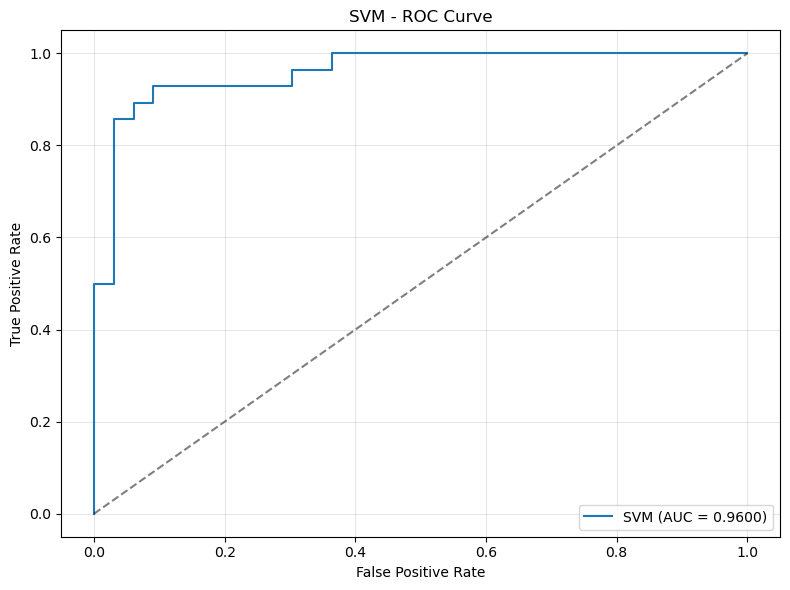

In [44]:
y_proba_svm = svm_grid.decision_function(X_test)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM - ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

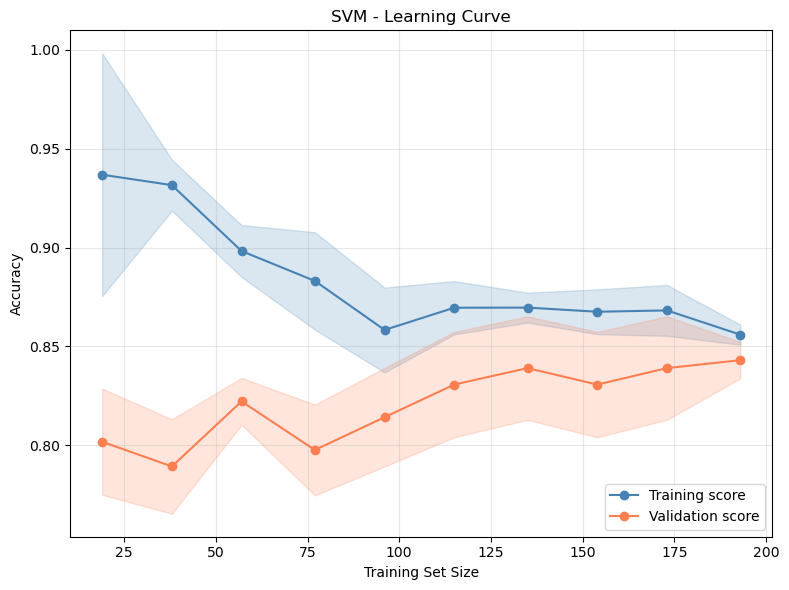

In [45]:
train_sizes, train_scores, val_scores = learning_curve(
    svm_grid.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='coral', label='Validation score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='coral')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('SVM - Learning Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

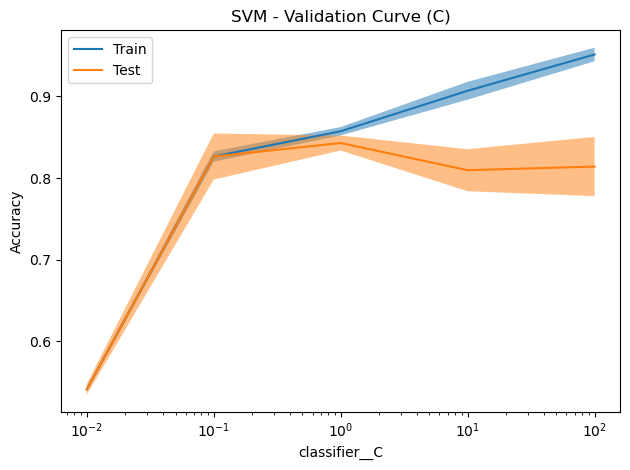

In [62]:
ValidationCurveDisplay.from_estimator(
    svm_grid.best_estimator_,
    X_train,
    y_train,
    param_name="classifier__C",
    param_range=[0.01, 0.1, 1, 10, 100],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
)
plt.title('SVM - Validation Curve (C)')
plt.tight_layout()
plt.show()

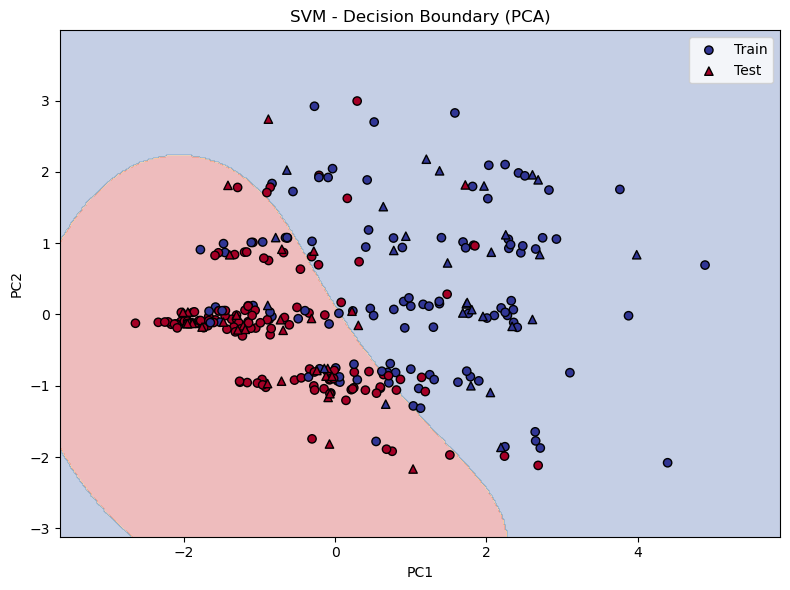

In [46]:
clf_pca = clone(svm_grid.best_estimator_.named_steps['classifier'])
clf_pca.fit(X_train_pca, y_train)

n_pc = X_train_pca.shape[1]

if n_pc == 1:
    x_min, x_max = X_train_pca.min() - 0.5, X_train_pca.max() + 0.5
    x_range = np.linspace(x_min, x_max, 1000).reshape(-1, 1)
    Z = clf_pca.predict(x_range)
    fig, ax = plt.subplots(figsize=(10, 2))
    for label, color in zip([0, 1], ['#cce5ff', '#ffcccc']):
        mask = Z.ravel() == label
        ax.axvspan(x_range[mask].min(), x_range[mask].max(), alpha=0.3, color=color)
    ax.scatter(X_train_pca[y_train == 0], np.zeros_like(X_train_pca[y_train == 0]),
               c='steelblue', edgecolors='k', s=40, label='Train 0', zorder=5)
    ax.scatter(X_train_pca[y_train == 1], np.zeros_like(X_train_pca[y_train == 1]),
               c='coral', edgecolors='k', s=40, label='Train 1', zorder=5, marker='s')
    ax.scatter(X_test_pca[y_test == 0], np.full_like(X_test_pca[y_test == 0], -0.1),
               c='steelblue', edgecolors='k', s=40, marker='^', label='Test 0', zorder=5)
    ax.scatter(X_test_pca[y_test == 1], np.full_like(X_test_pca[y_test == 1], -0.1),
               c='coral', edgecolors='k', s=40, marker='^', label='Test 1', zorder=5)
    ax.set_yticks([])
    ax.set_xlabel('PC1')
    ax.set_title('SVM - Decision Boundary (PCA 1D)')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
else:
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    if n_pc > 2:
        pad = np.zeros((grid_points.shape[0], n_pc - 2))
        grid_points = np.hstack([grid_points, pad])
    Z = clf_pca.predict(grid_points)
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.RdYlBu, label='Train')
    plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.RdYlBu, marker='^', label='Test')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('SVM - Decision Boundary (PCA)')
    plt.legend()
plt.tight_layout()
plt.show()

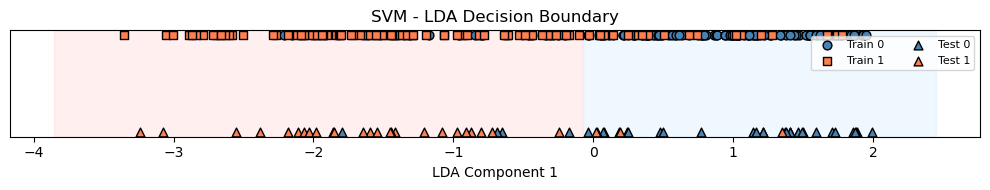

In [47]:
clf_lda = clone(svm_grid.best_estimator_.named_steps['classifier'])
clf_lda.fit(X_train_lda, y_train)

x_min, x_max = X_train_lda.min() - 0.5, X_train_lda.max() + 0.5
x_range = np.linspace(x_min, x_max, 1000).reshape(-1, 1)

Z = clf_lda.predict(x_range)

fig, ax = plt.subplots(figsize=(10, 2))
for label, color in zip([0, 1], ['#cce5ff', '#ffcccc']):
    mask = Z.ravel() == label
    ax.axvspan(x_range[mask].min(), x_range[mask].max(), alpha=0.3, color=color)

ax.scatter(X_train_lda[y_train == 0], np.zeros_like(X_train_lda[y_train == 0]),
           c='steelblue', edgecolors='k', s=40, label='Train 0', zorder=5)
ax.scatter(X_train_lda[y_train == 1], np.zeros_like(X_train_lda[y_train == 1]),
           c='coral', edgecolors='k', s=40, label='Train 1', zorder=5, marker='s')
ax.scatter(X_test_lda[y_test == 0], np.full_like(X_test_lda[y_test == 0], -0.1),
           c='steelblue', edgecolors='k', s=40, marker='^', label='Test 0', zorder=5)
ax.scatter(X_test_lda[y_test == 1], np.full_like(X_test_lda[y_test == 1], -0.1),
           c='coral', edgecolors='k', s=40, marker='^', label='Test 1', zorder=5)

ax.set_yticks([])
ax.set_xlabel('LDA Component 1')
ax.set_title('SVM - LDA Decision Boundary')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Model Comparison

In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'KNN': knn_grid,
    'Logistic Regression': lr_grid,
    'SVM': svm_grid,
}

rows = []
for name, grid in models.items():
    y_pred = grid.predict(X_test)
    rows.append({
        'Model': name,
        'CV Accuracy': grid.best_score_,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
    })

df_results = pd.DataFrame(rows).set_index('Model')

df_pct = (df_results * 100).round(2)

df_pct.style.highlight_max(color="#2fff0569", axis=0).format('{:.2f}%')


,CV Accuracy,Test Accuracy,Precision,Recall,F1-Score
Model,,,,,
KNN,84.30%,90.16%,89.29%,89.29%,89.29%
Logistic Regression,84.71%,88.52%,83.87%,92.86%,88.14%
SVM,84.30%,90.16%,86.67%,92.86%,89.66%
